# Next-Day PM2.5 Forecasting Using Machine Learning

## Objective

The objective of this notebook is to develop and compare machine-learning models for forecasting **next-day PM2.5 concentrations** across five Indian cities.

The models use information available on the current day and historical days, including:

- Current-day air pollutant concentrations
- Meteorological conditions
- Historical PM2.5 lag features
- Rolling PM2.5 statistics
- Calendar and seasonal information
- City information

Because the dataset has a temporal structure, model development and evaluation follow a **time-aware approach**. Future observations are not randomly mixed with past observations during model evaluation.

### Models Evaluated

1. Persistence Baseline
2. Linear Regression
3. Decision Tree Regressor
4. Random Forest Regressor
5. XGBoost Regressor

Model performance will be compared using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

The strongest models will subsequently undergo time-aware cross-validation and hyperparameter tuning.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

pd.set_option("display.max_columns", None)

RANDOM_STATE = 42

In [2]:
df = pd.read_csv(
    "pm25_next_day_forecasting_features.csv"
)

df["Date"] = pd.to_datetime(df["Date"])

df = (
    df
    .sort_values(["Date", "City"])
    .reset_index(drop=True)
)

print("Dataset shape:", df.shape)

print(
    "Date range:",
    df["Date"].min(),
    "to",
    df["Date"].max()
)

print("\nMissing values:", df.isna().sum().sum())

print("\nDuplicate City-Date rows:")
print(
    df.duplicated(
        subset=["City", "Date"]
    ).sum()
)

display(df.head())

Dataset shape: (3207, 25)
Date range: 2020-01-08 00:00:00 to 2021-12-30 00:00:00

Missing values: 0

Duplicate City-Date rows:
0


,Date,PM2.5,PM10,NO2,SO2,O3,CO,Temperature_Mean,Relative_Humidity_Mean,Precipitation,Wind_Speed_Max,Surface_Pressure_Mean,PM2.5_Lag1,PM2.5_Lag2,PM2.5_Lag3,PM2.5_Lag7,PM2.5_Rolling3_Mean,PM2.5_Rolling7_Mean,PM2.5_Rolling7_Std,Year,Month,Day_of_Week,Season,City,PM2.5_Next_Day
0,2020-01-08,31.501083,79.282609,33.996337,4.558495,46.321798,800.207985,22.5,67,0.0,16.4,914.1,24.838682,22.642570,51.294156,26.703125,26.327445,34.213316,13.425534,2020,1,2,Winter,Bengaluru,41.306190
1,2020-01-08,37.818907,61.834590,6.358947,27.412778,33.906346,547.894737,25.4,75,0.1,14.7,1012.2,29.295960,15.925365,13.734690,20.262949,27.680077,23.256471,8.462275,2020,1,2,Winter,Chennai,32.770514
2,2020-01-08,122.183095,148.136364,34.848894,9.403614,11.159524,1120.674043,12.8,92,17.5,14.5,988.9,126.446154,155.419504,173.386555,349.875000,134.682918,189.191787,68.025340,2020,1,2,Winter,Delhi,97.896274
3,2020-01-08,122.455102,220.020879,45.102000,10.188000,26.500769,1255.102041,17.7,80,0.0,8.9,1013.9,115.196364,102.015116,93.950549,121.902564,113.222194,93.766368,34.834783,2020,1,2,Winter,Kolkata,89.153933
4,2020-01-08,68.270000,104.341892,34.320862,8.277315,38.708889,866.755245,23.8,76,0.0,17.3,1012.4,94.860675,71.676000,97.626333,110.954359,78.268892,92.058904,19.772728,2020,1,2,Winter,Mumbai,62.421134


## 1. Time-Aware Train-Test Split

The dataset is divided chronologically rather than randomly.

Earlier observations are used for model training, while the most recent period is reserved as an unseen test set. This better represents a realistic forecasting scenario in which models are trained using historical information and evaluated on future observations.

All observations from the same calendar date are assigned to the same partition to prevent cities observed on the same date from being split across training and testing sets.

In [3]:
# Obtain sorted unique dates

unique_dates = np.sort(
    df["Date"].unique()
)

# Approximately 80% of dates for training

split_index = int(
    len(unique_dates) * 0.80
)

split_date = pd.Timestamp(
    unique_dates[split_index]
)

train_df = df[
    df["Date"] < split_date
].copy()

test_df = df[
    df["Date"] >= split_date
].copy()

print("Split date:", split_date.date())

print("\nTraining set:")
print("Rows:", len(train_df))
print(
    "Date range:",
    train_df["Date"].min().date(),
    "to",
    train_df["Date"].max().date()
)

print("\nTest set:")
print("Rows:", len(test_df))
print(
    "Date range:",
    test_df["Date"].min().date(),
    "to",
    test_df["Date"].max().date()
)

print(
    "\nTraining percentage:",
    round(len(train_df) / len(df) * 100, 2),
    "%"
)

print(
    "Test percentage:",
    round(len(test_df) / len(df) * 100, 2),
    "%"
)

# Verify no temporal overlap

assert train_df["Date"].max() < test_df["Date"].min()

print("\nTemporal leakage check passed.")

Split date: 2021-07-08

Training set:
Rows: 2563
Date range: 2020-01-08 to 2021-07-07

Test set:
Rows: 644
Date range: 2021-07-08 to 2021-12-30

Training percentage: 79.92 %
Test percentage: 20.08 %

Temporal leakage check passed.


## 2. Persistence Baseline Model

Before developing machine-learning models, a simple persistence baseline is established.

For next-day forecasting, the persistence model assumes that tomorrow's PM2.5 concentration will be equal to today's observed PM2.5 concentration:

> Predicted PM2.5(t+1) = PM2.5(t)

Air-pollution concentrations often exhibit temporal persistence, making this a meaningful benchmark. A machine-learning model should outperform this simple forecasting rule to demonstrate additional predictive value.

In [4]:
# Actual next-day PM2.5 values in the test period

y_test = test_df["PM2.5_Next_Day"].copy()

# Persistence forecast:
# Tomorrow's PM2.5 = today's PM2.5

baseline_predictions = test_df["PM2.5"].copy()

# Evaluation metrics

baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_predictions
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_predictions
)

baseline_results = pd.DataFrame({
    "Model": ["Persistence Baseline"],
    "MAE": [baseline_mae],
    "RMSE": [baseline_rmse],
    "R2": [baseline_r2]
})

display(
    baseline_results.round(3)
)

,Model,MAE,RMSE,R2
0,Persistence Baseline,12.995,25.285,0.843


## 3. Predictor Preparation and Preprocessing

Predictor variables are separated from the next-day PM2.5 target.

City and season are treated as categorical variables and encoded using one-hot encoding. Numerical predictors are standardized for the Linear Regression model.

The preprocessing transformations are fitted using only the training data through a scikit-learn pipeline, preventing information from the test period from influencing model preparation.

In [5]:
target = "PM2.5_Next_Day"

X_train = train_df.drop(
    columns=["Date", target]
).copy()

y_train = train_df[target].copy()

X_test = test_df.drop(
    columns=["Date", target]
).copy()

y_test = test_df[target].copy()

categorical_features = [
    "City",
    "Season"
]

numerical_features = [
    column
    for column in X_train.columns
    if column not in categorical_features
]

print("Training predictors shape:", X_train.shape)
print("Test predictors shape:", X_test.shape)

print("\nNumber of numerical features:")
print(len(numerical_features))

print("\nCategorical features:")
print(categorical_features)

print("\nTarget:")
print(target)

# Safety checks

assert target not in X_train.columns
assert "Date" not in X_train.columns

print("\nTarget leakage check passed.")

Training predictors shape: (2563, 23)
Test predictors shape: (644, 23)

Number of numerical features:
21

Categorical features:
['City', 'Season']

Target:
PM2.5_Next_Day

Target leakage check passed.


## 4. Linear Regression

Linear Regression is used as the first machine-learning model because it provides a simple and interpretable benchmark for evaluating whether the engineered predictors improve next-day PM2.5 forecasting beyond the persistence baseline.

In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numerical_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [8]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(
    X_train,
    y_train
)

linear_predictions = linear_model.predict(
    X_test
)

linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

linear_results = pd.DataFrame({
    "Model": ["Linear Regression"],
    "MAE": [linear_mae],
    "RMSE": [linear_rmse],
    "R2": [linear_r2]
})

comparison_so_far = pd.concat(
    [
        baseline_results,
        linear_results
    ],
    ignore_index=True
)

display(
    comparison_so_far.round(3)
)

,Model,MAE,RMSE,R2
0,Persistence Baseline,12.995,25.285,0.843
1,Linear Regression,14.276,24.246,0.855


### Linear Regression Performance

Linear Regression achieved an MAE of 14.276 µg/m³, an RMSE of 24.246 µg/m³, and an R² of 0.855.

Compared with the persistence baseline, Linear Regression produced a lower RMSE and a slightly higher R², indicating improved overall explanatory performance and a reduction in some larger forecasting errors. However, its MAE was higher than that of the persistence baseline.

Therefore, Linear Regression did not consistently outperform the persistence benchmark across all evaluation metrics. This highlights the importance of comparing forecasting models against a strong time-series baseline rather than relying on R² alone.

## 5. Decision Tree Regressor

A Decision Tree Regressor is evaluated to capture nonlinear relationships and interactions among pollutant concentrations, meteorological conditions, temporal variables, and historical PM2.5 features.

Unlike Linear Regression, a decision tree does not assume a linear relationship between predictors and next-day PM2.5. An initial untuned model is fitted to establish its baseline performance before any hyperparameter optimization.

In [9]:
decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeRegressor(
                random_state=RANDOM_STATE
            )
        )
    ]
)

decision_tree_model.fit(
    X_train,
    y_train
)

tree_predictions = decision_tree_model.predict(
    X_test
)

tree_mae = mean_absolute_error(
    y_test,
    tree_predictions
)

tree_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tree_predictions
    )
)

tree_r2 = r2_score(
    y_test,
    tree_predictions
)

tree_results = pd.DataFrame({
    "Model": ["Decision Tree"],
    "MAE": [tree_mae],
    "RMSE": [tree_rmse],
    "R2": [tree_r2]
})

comparison_so_far = pd.concat(
    [
        baseline_results,
        linear_results,
        tree_results
    ],
    ignore_index=True
)

display(
    comparison_so_far.round(3)
)

,Model,MAE,RMSE,R2
0,Persistence Baseline,12.995,25.285,0.843
1,Linear Regression,14.276,24.246,0.855
2,Decision Tree,16.257,31.024,0.763


### Decision Tree Performance

The untuned Decision Tree achieved an MAE of 16.257 µg/m³, an RMSE of 31.024 µg/m³, and an R² of 0.763.

Its performance was worse than both the persistence baseline and Linear Regression on the unseen test period. The poorer generalization of an unrestricted single decision tree may be associated with overfitting, which will be examined through training-versus-test performance and addressed through ensemble methods and model tuning.

## 6. Random Forest Regressor

A Random Forest Regressor is evaluated as an ensemble-based nonlinear forecasting model.

Random Forest combines predictions from multiple decision trees, which can reduce the instability and overfitting associated with a single tree while capturing complex nonlinear relationships and interactions among predictors.

An initial Random Forest model is fitted before hyperparameter tuning so that its baseline performance can be compared fairly with the previous models.

In [10]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

random_forest_model.fit(
    X_train,
    y_train
)

rf_predictions = random_forest_model.predict(
    X_test
)

rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

rf_results = pd.DataFrame({
    "Model": ["Random Forest"],
    "MAE": [rf_mae],
    "RMSE": [rf_rmse],
    "R2": [rf_r2]
})

comparison_so_far = pd.concat(
    [
        baseline_results,
        linear_results,
        tree_results,
        rf_results
    ],
    ignore_index=True
)

display(
    comparison_so_far.round(3)
)

,Model,MAE,RMSE,R2
0,Persistence Baseline,12.995,25.285,0.843
1,Linear Regression,14.276,24.246,0.855
2,Decision Tree,16.257,31.024,0.763
3,Random Forest,12.499,24.474,0.853


### Random Forest Performance

The Random Forest model achieved an MAE of 12.499 µg/m³, an RMSE of 24.474 µg/m³, and an R² of 0.853.

Random Forest produced the lowest MAE among the models evaluated so far and improved upon the persistence baseline in all three evaluation metrics. However, Linear Regression achieved a slightly lower RMSE and a slightly higher R².

These results indicate that no single model dominates across every evaluation criterion. The strong performance of the persistence baseline also demonstrates substantial day-to-day continuity in PM2.5 concentrations, making it an important benchmark for evaluating forecasting improvements.

In [11]:
# Training predictions
tree_train_predictions = decision_tree_model.predict(X_train)
rf_train_predictions = random_forest_model.predict(X_train)

# Training metrics
tree_train_mae = mean_absolute_error(
    y_train, tree_train_predictions
)
tree_train_rmse = np.sqrt(
    mean_squared_error(y_train, tree_train_predictions)
)
tree_train_r2 = r2_score(
    y_train, tree_train_predictions
)

rf_train_mae = mean_absolute_error(
    y_train, rf_train_predictions
)
rf_train_rmse = np.sqrt(
    mean_squared_error(y_train, rf_train_predictions)
)
rf_train_r2 = r2_score(
    y_train, rf_train_predictions
)

overfitting_check = pd.DataFrame({
    "Model": [
        "Decision Tree - Train",
        "Decision Tree - Test",
        "Random Forest - Train",
        "Random Forest - Test"
    ],
    "MAE": [
        tree_train_mae,
        tree_mae,
        rf_train_mae,
        rf_mae
    ],
    "RMSE": [
        tree_train_rmse,
        tree_rmse,
        rf_train_rmse,
        rf_rmse
    ],
    "R2": [
        tree_train_r2,
        tree_r2,
        rf_train_r2,
        rf_r2
    ]
})

display(overfitting_check.round(3))

,Model,MAE,RMSE,R2
0,Decision Tree - Train,0.000,0.000,1.000
1,Decision Tree - Test,16.257,31.024,0.763
2,Random Forest - Train,4.805,12.129,0.954
3,Random Forest - Test,12.499,24.474,0.853


### Assessment of Model Overfitting

The Decision Tree model achieved nearly perfect performance on the training data (R² = 1.000) but substantially lower performance on the test data (R² = 0.763), indicating severe overfitting.

The Random Forest model showed considerably better generalization. Its training R² was 0.954 compared with a test R² of 0.853. Although some difference between training and test performance remains, ensemble averaging substantially reduced the overfitting observed in the individual Decision Tree.

Therefore, further model development focuses on improving generalization through controlled model tuning and comparison with additional forecasting approaches.

In [12]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

# Time-aware cross-validation
tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [8, 12, 16, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", 0.7, 1.0]
}

rf_search = RandomizedSearchCV(
    estimator=random_forest_model,
    param_distributions=param_grid,
    n_iter=20,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)

print("Best parameters:")
print(rf_search.best_params_)

print("\nBest cross-validation MAE:")
print(round(-rf_search.best_score_, 3))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters:
{'model__n_estimators': 500, 'model__min_samples_split': 10, 'model__min_samples_leaf': 4, 'model__max_features': 0.7, 'model__max_depth': None}

Best cross-validation MAE:
14.263


In [13]:
# Best tuned Random Forest selected using training-set CV
tuned_rf_model = rf_search.best_estimator_

# Predict on the untouched test set
tuned_rf_predictions = tuned_rf_model.predict(X_test)

# Test metrics
tuned_rf_mae = mean_absolute_error(
    y_test,
    tuned_rf_predictions
)

tuned_rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tuned_rf_predictions
    )
)

tuned_rf_r2 = r2_score(
    y_test,
    tuned_rf_predictions
)

# Compare all models evaluated so far
final_comparison = pd.DataFrame({
    "Model": [
        "Persistence Baseline",
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "MAE": [
        baseline_mae,
        linear_mae,
        tree_mae,
        rf_mae,
        tuned_rf_mae
    ],
    "RMSE": [
        baseline_rmse,
        linear_rmse,
        tree_rmse,
        rf_rmse,
        tuned_rf_rmse
    ],
    "R2": [
        baseline_r2,
        linear_r2,
        tree_r2,
        rf_r2,
        tuned_rf_r2
    ]
})

display(final_comparison.round(3))

,Model,MAE,RMSE,R2
0,Persistence Baseline,12.995,25.285,0.843
1,Linear Regression,14.276,24.246,0.855
2,Decision Tree,16.257,31.024,0.763
3,Random Forest,12.499,24.474,0.853
4,Tuned Random Forest,12.349,24.210,0.856


In [14]:
# Create dataframe containing test observations and tuned RF predictions
city_results = X_test[["City"]].copy()

city_results["Actual_PM2.5"] = y_test.values
city_results["Predicted_PM2.5"] = tuned_rf_predictions

# Calculate metrics separately for each city
city_metrics = []

for city in city_results["City"].unique():

    city_data = city_results[
        city_results["City"] == city
    ]

    mae = mean_absolute_error(
        city_data["Actual_PM2.5"],
        city_data["Predicted_PM2.5"]
    )

    rmse = np.sqrt(
        mean_squared_error(
            city_data["Actual_PM2.5"],
            city_data["Predicted_PM2.5"]
        )
    )

    r2 = r2_score(
        city_data["Actual_PM2.5"],
        city_data["Predicted_PM2.5"]
    )

    city_metrics.append({
        "City": city,
        "Observations": len(city_data),
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

city_performance = pd.DataFrame(city_metrics)

display(
    city_performance
    .sort_values("MAE")
    .round(3)
)

,City,Observations,MAE,RMSE,R2
0,Bengaluru,118,6.751,9.637,0.677
4,Mumbai,136,8.363,11.365,0.859
1,Chennai,136,8.899,12.249,0.600
3,Kolkata,118,11.026,15.135,0.827
2,Delhi,136,25.791,47.085,0.792


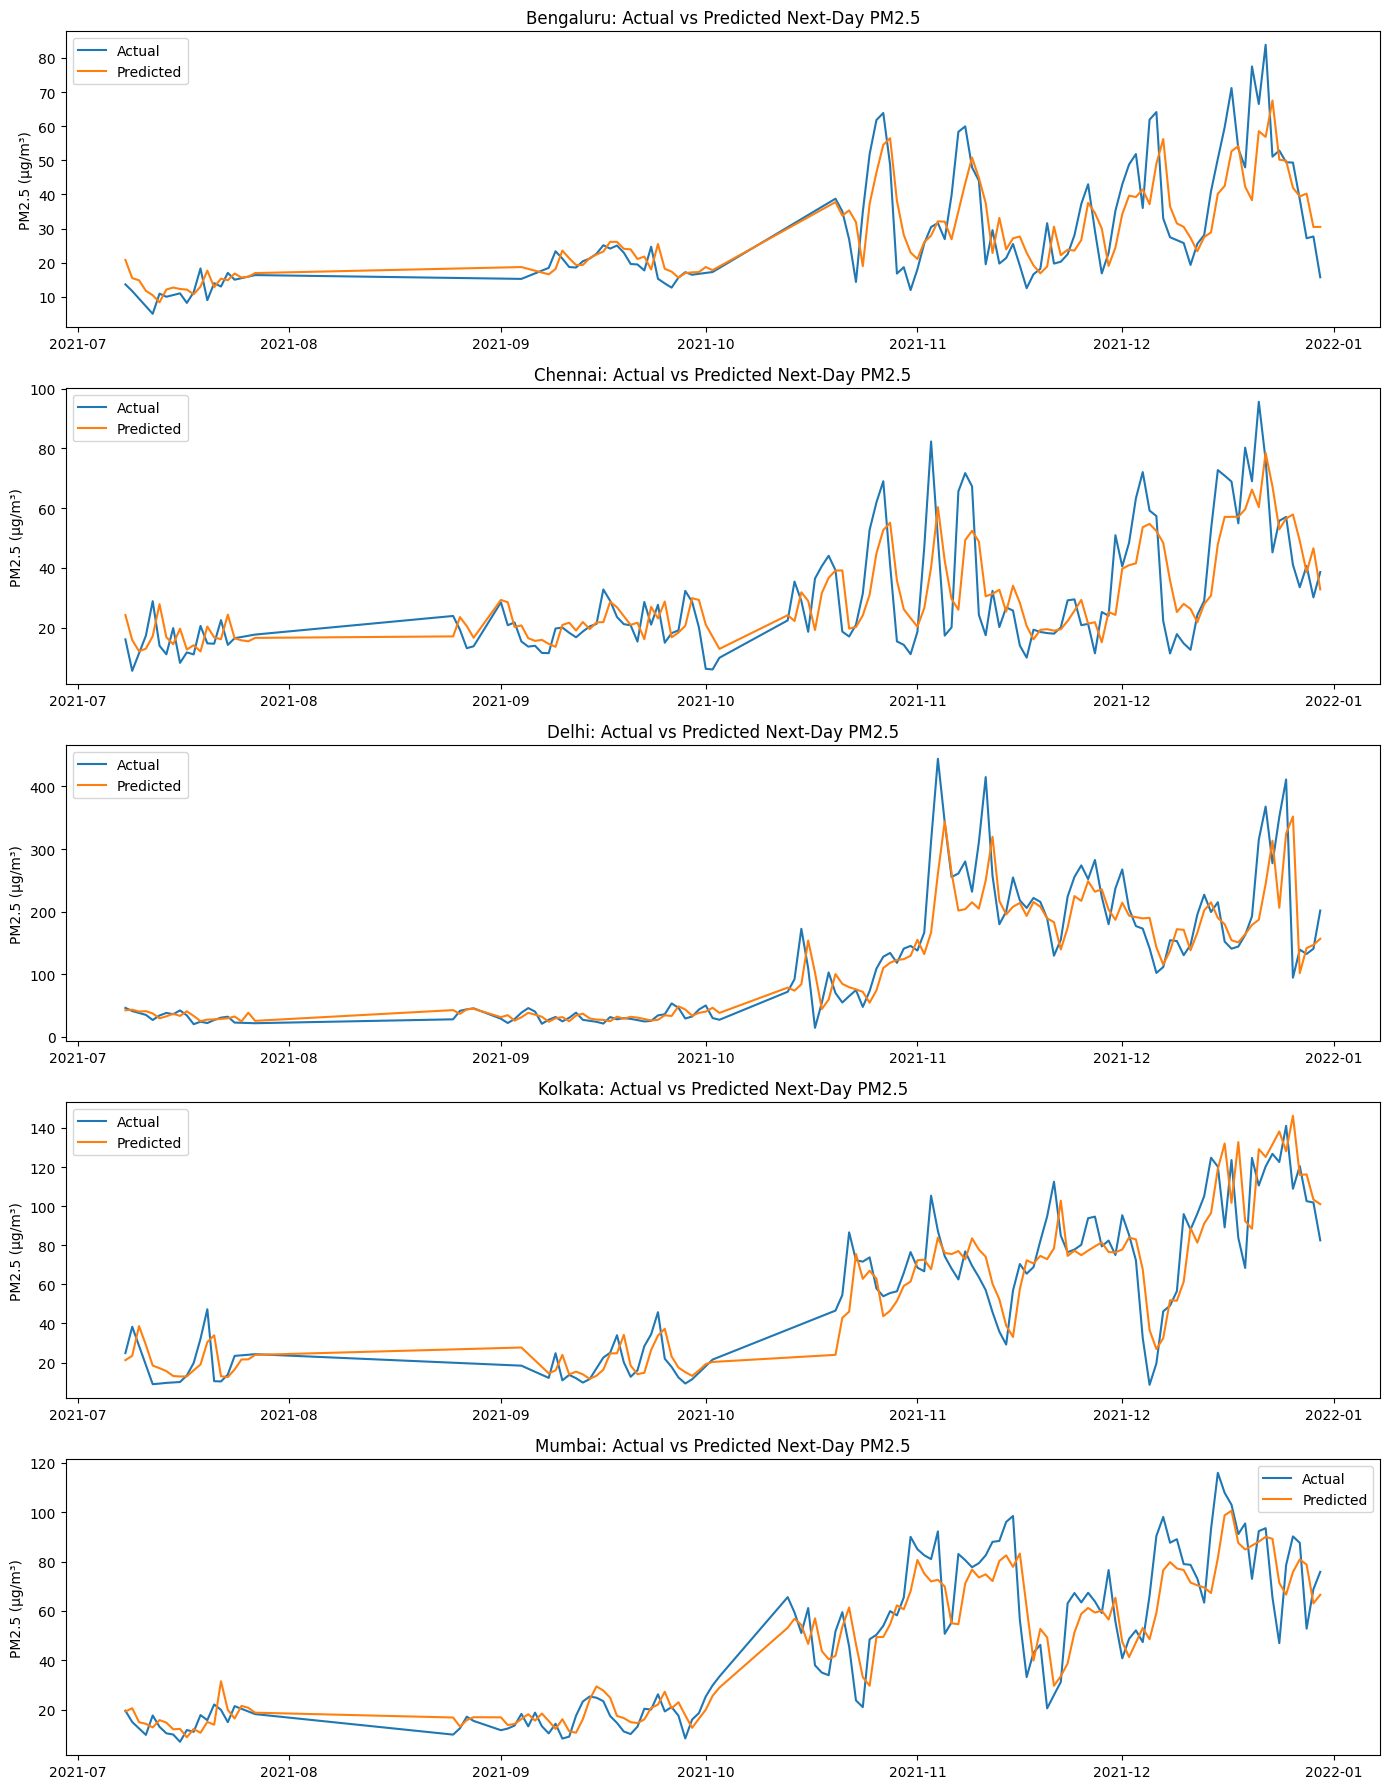

In [17]:
# Prepare prediction dataframe
# Retrieve dates from the original dataframe using the test-set indices

prediction_results = pd.DataFrame({
    "Date": df.loc[X_test.index, "Date"].values,
    "City": X_test["City"].values,
    "Actual_PM2.5": y_test.values,
    "Predicted_PM2.5": tuned_rf_predictions
})

prediction_results = (
    prediction_results
    .sort_values(["City", "Date"])
    .reset_index(drop=True)
)

# Plot actual vs predicted PM2.5 for each city

cities = prediction_results["City"].unique()

fig, axes = plt.subplots(
    len(cities),
    1,
    figsize=(14, 18),
    sharex=False
)

for ax, city in zip(axes, cities):

    city_data = prediction_results[
        prediction_results["City"] == city
    ]

    ax.plot(
        city_data["Date"],
        city_data["Actual_PM2.5"],
        label="Actual",
        linewidth=1.5
    )

    ax.plot(
        city_data["Date"],
        city_data["Predicted_PM2.5"],
        label="Predicted",
        linewidth=1.5
    )

    ax.set_title(
        f"{city}: Actual vs Predicted Next-Day PM2.5"
    )

    ax.set_ylabel("PM2.5 (µg/m³)")
    ax.legend()

plt.tight_layout()
plt.show()

## 15. Forecast Error Analysis

To further evaluate the tuned Random Forest model, prediction errors were examined on the unseen test period. Residual analysis helps identify systematic prediction bias and determine whether forecast errors become larger during high-pollution episodes.

In [18]:
# Calculate prediction errors

prediction_results["Residual"] = (
    prediction_results["Actual_PM2.5"]
    - prediction_results["Predicted_PM2.5"]
)

prediction_results["Absolute_Error"] = (
    prediction_results["Residual"].abs()
)

print("Overall residual summary:")
print(
    prediction_results["Residual"]
    .describe()
    .round(3)
)

print("\nMean Error (Actual - Predicted):")
print(
    round(
        prediction_results["Residual"].mean(),
        3
    )
)

Overall residual summary:
count    644.000
mean       2.051
std       24.142
min     -257.676
25%       -5.751
50%       -0.305
75%        7.337
max      183.747
Name: Residual, dtype: float64

Mean Error (Actual - Predicted):
2.051


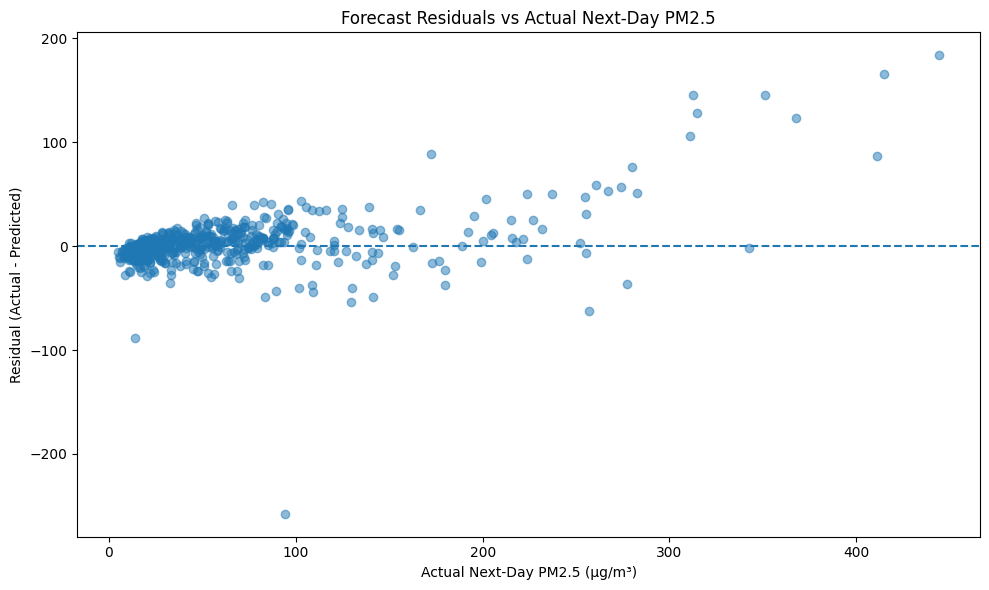

In [19]:
plt.figure(figsize=(10, 6))

plt.scatter(
    prediction_results["Actual_PM2.5"],
    prediction_results["Residual"],
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Actual Next-Day PM2.5 (µg/m³)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title(
    "Forecast Residuals vs Actual Next-Day PM2.5"
)

plt.tight_layout()
plt.show()

### Interpretation of Forecast Errors

The tuned Random Forest showed relatively low overall prediction bias, with a mean residual of 2.05 µg/m³ and a median residual close to zero (-0.31 µg/m³). This indicates that the model does not systematically overpredict or underpredict PM2.5 concentrations under typical conditions.

However, the residual plot shows that prediction errors become substantially larger at high PM2.5 concentrations. Several large positive residuals indicate that the model tends to underestimate the magnitude of some extreme pollution episodes. Therefore, while the model performs well for general next-day PM2.5 forecasting, its accuracy is comparatively weaker during abrupt and unusually severe pollution events.

In [20]:
# Extract fitted preprocessor and Random Forest
fitted_preprocessor = tuned_rf_model.named_steps["preprocessor"]
fitted_rf = tuned_rf_model.named_steps["model"]

# Get transformed feature names
feature_names = fitted_preprocessor.get_feature_names_out()

# Get Random Forest feature importances
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": fitted_rf.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

display(feature_importance.head(15).round(4))

,Feature,Importance
0,numeric__PM2.5,0.5618
1,numeric__PM2.5_Rolling3_Mean,0.1590
2,numeric__PM2.5_Rolling7_Mean,0.0731
3,numeric__PM10,0.0489
4,numeric__CO,0.0229
5,numeric__PM2.5_Lag1,0.0156
6,numeric__PM2.5_Rolling7_Std,0.0153
7,numeric__NO2,0.0141
8,numeric__Temperature_Mean,0.0130
9,numeric__PM2.5_Lag2,0.0123


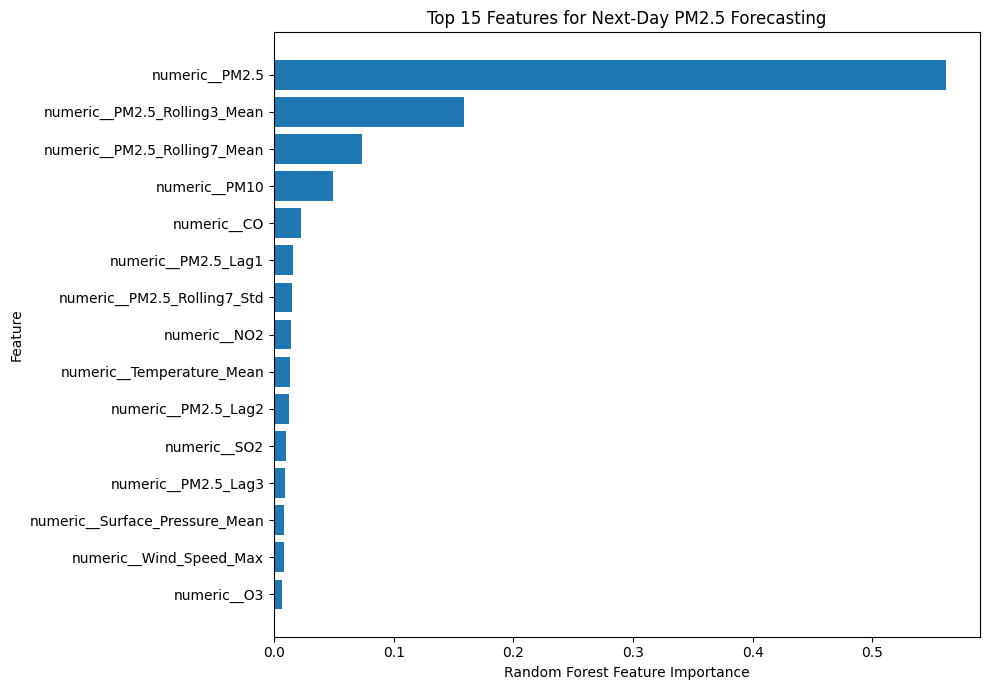

In [21]:
# Plot top 15 most important forecasting features

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Random Forest Feature Importance")
plt.ylabel("Feature")
plt.title(
    "Top 15 Features for Next-Day PM2.5 Forecasting"
)

plt.tight_layout()
plt.show()

### Interpretation of Feature Importance

Feature importance from the tuned Random Forest indicates that recent PM2.5 conditions are the strongest predictors of next-day PM2.5 concentrations.

Current-day PM2.5 was the dominant predictor, accounting for approximately 56% of total feature importance. The 3-day and 7-day rolling PM2.5 averages were also highly influential, indicating strong temporal persistence in daily air-pollution levels.

Among the additional pollutants, PM10 contributed the greatest predictive information, while CO and NO2 had smaller contributions. Individual meteorological variables showed comparatively lower feature importance after recent pollution history was included in the model.

These importance values represent predictive contribution within the Random Forest model and should not be interpreted as evidence of causal relationships.

## 17. Forecast Performance During High-Pollution Episodes

Overall forecasting metrics may conceal differences in model performance between ordinary and severe pollution conditions. Since the residual analysis indicated larger prediction errors at high PM2.5 concentrations, forecast accuracy was evaluated separately across different pollution-severity levels.

In [22]:
# Classify observations by actual next-day PM2.5 level

def pollution_level(pm25):
    if pm25 <= 60:
        return "Lower (≤60)"
    elif pm25 <= 120:
        return "Elevated (61–120)"
    else:
        return "High (>120)"

prediction_results["Pollution_Level"] = (
    prediction_results["Actual_PM2.5"]
    .apply(pollution_level)
)

severity_results = []

for level, group in prediction_results.groupby(
    "Pollution_Level",
    observed=True
):

    severity_results.append({
        "Pollution_Level": level,
        "Observations": len(group),
        "MAE": mean_absolute_error(
            group["Actual_PM2.5"],
            group["Predicted_PM2.5"]
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                group["Actual_PM2.5"],
                group["Predicted_PM2.5"]
            )
        ),
        "Mean_Error": (
            group["Actual_PM2.5"]
            - group["Predicted_PM2.5"]
        ).mean()
    })

severity_performance = pd.DataFrame(
    severity_results
)

display(
    severity_performance.round(3)
)

,Pollution_Level,Observations,MAE,RMSE,Mean_Error
0,Elevated (61–120),129,16.951,29.613,5.149
1,High (>120),71,37.062,55.290,23.123
2,Lower (≤60),444,7.061,10.322,-2.219


### Interpretation of Performance Across Pollution Levels

Forecast accuracy varied considerably across pollution-severity levels. The tuned Random Forest performed best for lower PM2.5 concentrations (≤60 µg/m³), with an MAE of 7.06 µg/m³ and RMSE of 10.32 µg/m³.

Prediction errors increased for elevated concentrations (61–120 µg/m³), while the largest errors occurred during high-pollution episodes (>120 µg/m³), where the MAE reached 37.06 µg/m³ and RMSE reached 55.29 µg/m³.

The positive mean error of 23.12 µg/m³ for high-pollution observations indicates a tendency to underestimate severe pollution episodes. This confirms the pattern observed in the residual and actual-versus-predicted plots.

Therefore, although the model provides strong overall next-day forecasting performance, its predictions should be interpreted more cautiously during extreme pollution events.

## 18. Final Forecasting Model Summary

Four forecasting approaches were evaluated using a chronological train-test split: a persistence baseline, Linear Regression, Decision Tree, and Random Forest. Hyperparameter tuning of the Random Forest was performed using time-aware cross-validation on the training data.

The tuned Random Forest achieved the best overall test performance, with an MAE of 12.35 µg/m³, RMSE of 24.21 µg/m³, and R² of 0.856. Its improvement over the untuned Random Forest and persistence baseline was modest but consistent across the principal evaluation metrics.

City-level evaluation showed that forecasting performance varied geographically. Mumbai and Kolkata showed strong predictive performance, while Delhi had substantially larger absolute errors because of its higher concentrations and more extreme pollution fluctuations.

Feature-importance analysis showed that current PM2.5 and recent rolling PM2.5 averages were the dominant forecasting predictors, demonstrating strong short-term temporal persistence in air-pollution concentrations. PM10 also contributed useful predictive information, while individual meteorological variables had smaller importance after recent pollution history was included.

Residual and pollution-severity analyses revealed the principal limitation of the forecasting model: prediction errors increased considerably during extreme pollution episodes, with the model tending to underestimate some severe PM2.5 spikes.

Overall, the tuned Random Forest provides a strong model for next-day PM2.5 forecasting under typical conditions, while extreme pollution events remain substantially more difficult to predict accurately.

## 19. Forecasting Design and Leakage Prevention

The forecasting task was formulated as a one-day-ahead prediction problem, where information available for day *t* was used to predict PM2.5 concentration on day *t+1*.

The predictor set included current-day pollution and meteorological conditions, historical PM2.5 lag variables, rolling PM2.5 statistics, calendar variables, season, and city.

To preserve the temporal structure of the forecasting problem:

- Lag features were constructed separately within each city.
- The prediction target was generated by shifting PM2.5 one day forward within each city.
- Training and testing data were separated chronologically rather than through random sampling.
- The final test period was kept separate from model training and hyperparameter selection.
- Random Forest hyperparameter tuning used time-aware cross-validation on the training data only.

This design reduces temporal data leakage and provides a more realistic evaluation of next-day forecasting performance.

### Forecasting Assumption

The forecasting model uses pollutant and meteorological measurements observed on the current day to predict PM2.5 for the following day. Therefore, the model represents an end-of-day next-day forecasting framework.

For operational forecasting earlier in the day, some same-day measurements may not yet be fully available and would need to be replaced by real-time observations or separately forecast meteorological inputs.